# ACO

In [ ]:
import pandas as pd
import numpy as np
import random
from math import sqrt
from  geopy.distance import geodesic
import matplotlib.pyplot as plt
from numba import jit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from math import radians, sin, cos, sqrt, atan2

In [ ]:
# ID dan nama sheet
sheet_id = "1z_IKjtY56_VK5hd-2YxBjuvgwJkEko5FVPm1JXIveO4"
sheet_name = "Sheet1"

# Akses data sebagai CSV
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"

# Baca dataframe
dataset = pd.read_csv(url)
dataset.head()

,No,Place,Coordinates,Start_time,End_time,Service_Time,start_time_dec,end_time_dec,service_time_dec
0,1,LBB Nurul Fikri,"-7.322512479985737, 112.77876084047776",8:00,17:00,0,"8,00","17,00","0,00"
1,2,SMA Negeri 1 Surabaya,"-7.257242833292316, 112.74916690952959",6:30,15:00,25,"6,50","15,00","0,42"
2,3,SMA Negeri 2 Surabaya,"-7.256427756879855, 112.74938016427122",6:30,17:00,20,"6,50","17,00","0,33"
3,4,SMA Negeri 3 Surabaya,"-7.2413221513779344, 112.79045296382363",6:30,15:15,18,"6,50","15,25","0,30"
4,5,SMA Negeri 4 Surabaya,"-7.264745426779094, 112.75501295696357",6:30,16:00,21,"6,50","16,00","0,35"


In [ ]:
# Muat dataset
df=dataset.copy()

# --- PERSIAPAN DATA (Sama seperti sebelumnya) ---

def time_to_minutes(time_str): h, m = map(int, time_str.split(':')); return h * 60 + m
df['start_minutes'] = df['Start_time'].apply(time_to_minutes)
df['end_minutes'] = df['End_time'].apply(time_to_minutes)
df[['latitude', 'longitude']] = df['Coordinates'].str.split(', *', expand=True, regex=True).astype(float)

all_locations_data = df.reset_index(drop=True)
depot = all_locations_data.iloc[0]
locations = all_locations_data.iloc[1:]
AVERAGE_SPEED_KMPH = 40.0
DAILY_TIME_CAPACITY = depot['end_minutes'] - depot['start_minutes']

@jit(nopython=True) # Percepat fungsi Haversine dengan Numba
def haversine_distance_numba(lat1, lon1, lat2, lon2):
    R = 6371.0
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    a = math.sin(dLat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dLon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

In [ ]:
# --- ADAPTASI UNTUK NUMBA ---
# Ekstrak data dari Pandas ke NumPy Array SEKALI SAJA di awal
start_times_np = all_locations_data['start_minutes'].to_numpy(dtype=np.float64)
end_times_np = all_locations_data['end_minutes'].to_numpy(dtype=np.float64)
service_times_np = all_locations_data['Service_Time'].to_numpy(dtype=np.float64)
depot_idx = 0

# Buat distance matrix menggunakan fungsi Haversine yang sudah di-JIT
num_locations = len(all_locations_data)
distance_matrix = np.zeros((num_locations, num_locations), dtype=np.float64)
lats_np = all_locations_data['latitude'].to_numpy(dtype=np.float64)
lons_np = all_locations_data['longitude'].to_numpy(dtype=np.float64)
for i in range(num_locations):
    for j in range(num_locations):
        distance_matrix[i, j] = haversine_distance_numba(lats_np[i], lons_np[i], lats_np[j], lons_np[j])


# --- FUNGSI EVALUASI YANG DIPERCEPAT NUMBA ---
@jit(nopython=True)
def evaluate_single_route_numba(route_indices, distance_matrix, start_times, end_times, service_times):
    """Versi fungsi evaluasi yang kompatibel dan dipercepat oleh Numba."""
    full_route = np.concatenate((np.array([depot_idx]), route_indices, np.array([depot_idx])))
    distance = 0.0
    current_time = start_times[depot_idx]

    for i in range(len(full_route) - 1):
        from_idx = full_route[i]
        to_idx = full_route[i+1]

        dist = distance_matrix[from_idx, to_idx]
        travel_time = (dist / AVERAGE_SPEED_KMPH) * 60.0
        distance += dist

        arrival_time = current_time + travel_time
        if arrival_time > end_times[to_idx]:
            return np.inf, np.inf

        current_time = max(arrival_time, start_times[to_idx]) + service_times[to_idx]

    total_duration = current_time - start_times[depot_idx]
    if total_duration > DAILY_TIME_CAPACITY:
        return np.inf, np.inf

    return total_duration, distance

In [ ]:
# --- FUNGSI EVALUASI YANG DIPERCEPAT NUMBA ---
@jit(nopython=True)
def evaluate_single_route_numba(route_indices, distance_matrix, start_times, end_times, service_times):
    """Versi fungsi evaluasi yang kompatibel dan dipercepat oleh Numba."""
    full_route = np.concatenate((np.array([depot_idx]), route_indices, np.array([depot_idx])))
    distance = 0.0
    current_time = start_times[depot_idx]

    for i in range(len(full_route) - 1):
        from_idx = full_route[i]
        to_idx = full_route[i+1]

        dist = distance_matrix[from_idx, to_idx]
        travel_time = (dist / AVERAGE_SPEED_KMPH) * 60.0
        distance += dist

        arrival_time = current_time + travel_time
        if arrival_time > end_times[to_idx]:
            return np.inf, np.inf

        current_time = max(arrival_time, start_times[to_idx]) + service_times[to_idx]

    total_duration = current_time - start_times[depot_idx]
    if total_duration > DAILY_TIME_CAPACITY:
        return np.inf, np.inf

    return total_duration, distance

#Versi fungsi evaluasi non-Numba (untuk reporting & visualisasi yang butuh Pandas)
def evaluate_single_route_pandas(route_indices, all_data, distance_matrix):
    full_route = [depot.name] + route_indices + [depot.name]
    distance, current_time = 0.0, depot['start_minutes']
    for i in range(len(full_route) - 1):
        from_idx, to_idx = full_route[i], full_route[i+1]
        dist = distance_matrix[from_idx, to_idx]
        travel_time = (dist / AVERAGE_SPEED_KMPH) * 60.0
        distance += dist
        to_loc = all_data.loc[to_idx]
        arrival_time = current_time + travel_time
        if arrival_time > to_loc['end_minutes']: return float('inf'), float('inf')
        current_time = max(arrival_time, to_loc['start_minutes']) + to_loc['Service_Time']
    total_duration = current_time - depot['start_minutes']
    if total_duration > DAILY_TIME_CAPACITY: return float('inf'), float('inf')
    return total_duration, distance

# --- IMPLEMENTASI UTAMA ACO (Dimodifikasi untuk memanggil fungsi Numba) ---
def run_aco_cvrptw_numba(
    locations_to_visit, distance_matrix, start_times, end_times, service_times,
    n_ants=20, n_iterations=300, alpha=0.2, beta=6.0, rho=0.2, Q=50, seed=42, verbose=True
):
    # Set random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)

    location_indices_np = locations_to_visit.index.to_numpy(dtype=np.int64)
    num_total_locations = len(distance_matrix)

    pheromone_matrix = np.ones((num_total_locations, num_total_locations))
    heuristic_matrix = 1.0 / (distance_matrix + 1e-10)

    best_solution_ever = []
    best_distance_ever = float('inf')

    convergence_aco = []  # Track best distance over iterations

    for it in range(n_iterations):
        all_ant_solutions = []

        for ant in range(n_ants):
            unvisited = list(location_indices_np)
            ant_routes = []
            ant_total_distance = 0.0

            while unvisited:
                current_route_indices = []
                current_route_path = [0]  # depot_idx = 0

                while True:
                    last_loc_idx = current_route_path[-1]
                    # Cari lokasi yang valid untuk dikunjungi berikutnya
                    possible_next_moves = [
                        loc for loc in unvisited
                        if evaluate_single_route_numba(
                            np.array(current_route_indices + [loc]),
                            distance_matrix, start_times, end_times, service_times
                        )[0] != np.inf
                    ]

                    if not possible_next_moves:
                        break

                    probs = np.array([
                        (pheromone_matrix[last_loc_idx, move] ** alpha) *
                        (heuristic_matrix[last_loc_idx, move] ** beta)
                        for move in possible_next_moves
                    ], dtype=np.float64)

                    probs_sum = np.sum(probs)

                    if probs_sum == 0:
                        chosen_loc = random.choice(possible_next_moves)
                    else:
                        chosen_loc = random.choices(
                            possible_next_moves,
                            weights=probs / probs_sum,
                            k=1
                        )[0]

                    current_route_indices.append(chosen_loc)
                    current_route_path.append(chosen_loc)
                    unvisited.remove(chosen_loc)

                if current_route_indices:
                    ant_routes.append(current_route_indices)
                    _, route_dist = evaluate_single_route_numba(
                        np.array(current_route_indices),
                        distance_matrix, start_times, end_times, service_times
                    )
                    ant_total_distance += route_dist

            all_ant_solutions.append({
                'routes': ant_routes,
                'distance': ant_total_distance
            })

        # Cari semut terbaik di iterasi ini
        best_ant_in_iteration = min(all_ant_solutions, key=lambda x: x['distance'])

        if best_ant_in_iteration['distance'] < best_distance_ever:
            best_distance_ever = best_ant_in_iteration['distance']
            best_solution_ever = best_ant_in_iteration['routes']

        convergence_aco.append(best_distance_ever)  # Simpan untuk convergence graph

        # Update pheromone
        pheromone_matrix *= (1 - rho)
        if best_ant_in_iteration['routes']:
            for route in best_ant_in_iteration['routes']:
                path = [0] + route + [0]
                for i in range(len(path) - 1):
                    pheromone_matrix[path[i], path[i + 1]] += Q / best_distance_ever
                    pheromone_matrix[path[i + 1], path[i]] += Q / best_distance_ever

        if verbose and (it + 1) % 10 == 0:
            print(f"Iterasi {it + 1}: Jarak Terbaik = {best_distance_ever:.2f} km")

    return best_solution_ever, convergence_aco

# --- Langkah 5: Fungsi Visualisasi Universal ---
def visualize_solution(routes, algorithm_name, all_data, distance_matrix):
    """Fungsi untuk mencetak detail dan memplot hasil optimasi."""
    plt.figure(figsize=(15, 12))
    if not routes or not routes[0]:
        print(f"Tidak ada solusi valid yang ditemukan oleh {algorithm_name}.")
        plt.title(f'Gagal Menemukan Solusi - {algorithm_name}')
        plt.show()
        return

    total_dist_final = 0

    print(f"\n--- HASIL OPTIMASI FINAL DENGAN {algorithm_name} ---")
    for i, route_indices in enumerate(routes):
        # Gunakan fungsi non-numba untuk mendapatkan nama tempat dan reporting
        time, dist = evaluate_single_route_pandas(route_indices, all_data, distance_matrix)
        if dist == float('inf'): continue # Lewati jika rute tidak valid

        total_dist_final += dist
        route_places = ['Depot'] + [all_data.loc[idx, 'Place'] for idx in route_indices] + ['Depot']

        print(f"\nHari ke-{i+1}:")
        print(f"  Rute: {' -> '.join(route_places)}")
        print(f"  Jarak: {dist:.2f} km")
        print(f"  Waktu: {time:.2f} menit")

        # Ambil koordinat untuk diplot
        route_coords = [(all_data.loc[idx, 'longitude'], all_data.loc[idx, 'latitude']) for idx in [depot.name] + route_indices + [depot.name]]
        lons, lats = zip(*route_coords)
        plt.plot(lons, lats, marker='o', linestyle='-', label=f'Rute Hari {i+1}')

    print(f"\n=======================================================")
    print(f"TOTAL JARAK KESELURUHAN ({algorithm_name}): {total_dist_final:.2f} km")
    print(f"=======================================================")

    # Plot semua titik lokasi
    plt.scatter(all_data['longitude'][1:], all_data['latitude'][1:], c='gray', alpha=0.5, label='Lokasi Sekolah')
    plt.scatter(depot['longitude'], depot['latitude'], c='red', marker='s', s=200, label='Depot', zorder=5)

    # Anotasi nama tempat
    for idx, row in all_data.iterrows():
        plt.text(row['longitude'], row['latitude'] + 0.0005, str(idx), fontsize=14, ha='center')

    plt.title(f'Hasil Optimasi Rute dengan {algorithm_name}', fontsize=16)
    plt.xlabel('Longitude', fontsize=12)
    plt.ylabel('Latitude', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Memulai Optimasi dengan ACO yang dipercepat Numba...
Iterasi 10: Jarak Terbaik = 126.70 km
Iterasi 20: Jarak Terbaik = 125.17 km
Iterasi 30: Jarak Terbaik = 125.17 km
Iterasi 40: Jarak Terbaik = 123.81 km
Iterasi 50: Jarak Terbaik = 123.38 km
Iterasi 60: Jarak Terbaik = 122.56 km
Iterasi 70: Jarak Terbaik = 121.94 km
Iterasi 80: Jarak Terbaik = 121.94 km
Iterasi 90: Jarak Terbaik = 121.94 km
Iterasi 100: Jarak Terbaik = 121.55 km
Iterasi 110: Jarak Terbaik = 120.01 km
Iterasi 120: Jarak Terbaik = 120.01 km
Iterasi 130: Jarak Terbaik = 118.08 km
Iterasi 140: Jarak Terbaik = 118.08 km
Iterasi 150: Jarak Terbaik = 118.08 km
Iterasi 160: Jarak Terbaik = 118.08 km
Iterasi 170: Jarak Terbaik = 118.08 km
Iterasi 180: Jarak Terbaik = 118.08 km
Iterasi 190: Jarak Terbaik = 117.96 km
Iterasi 200: Jarak Terbaik = 117.96 km
Iterasi 210: Jarak Terbaik = 117.62 km
Iterasi 220: Jarak Terbaik = 117.62 km
Iterasi 230: Jarak Terbaik = 117.05 km
Iterasi 240: Jarak Terbaik = 117.05 km
Iterasi 250: Jarak T

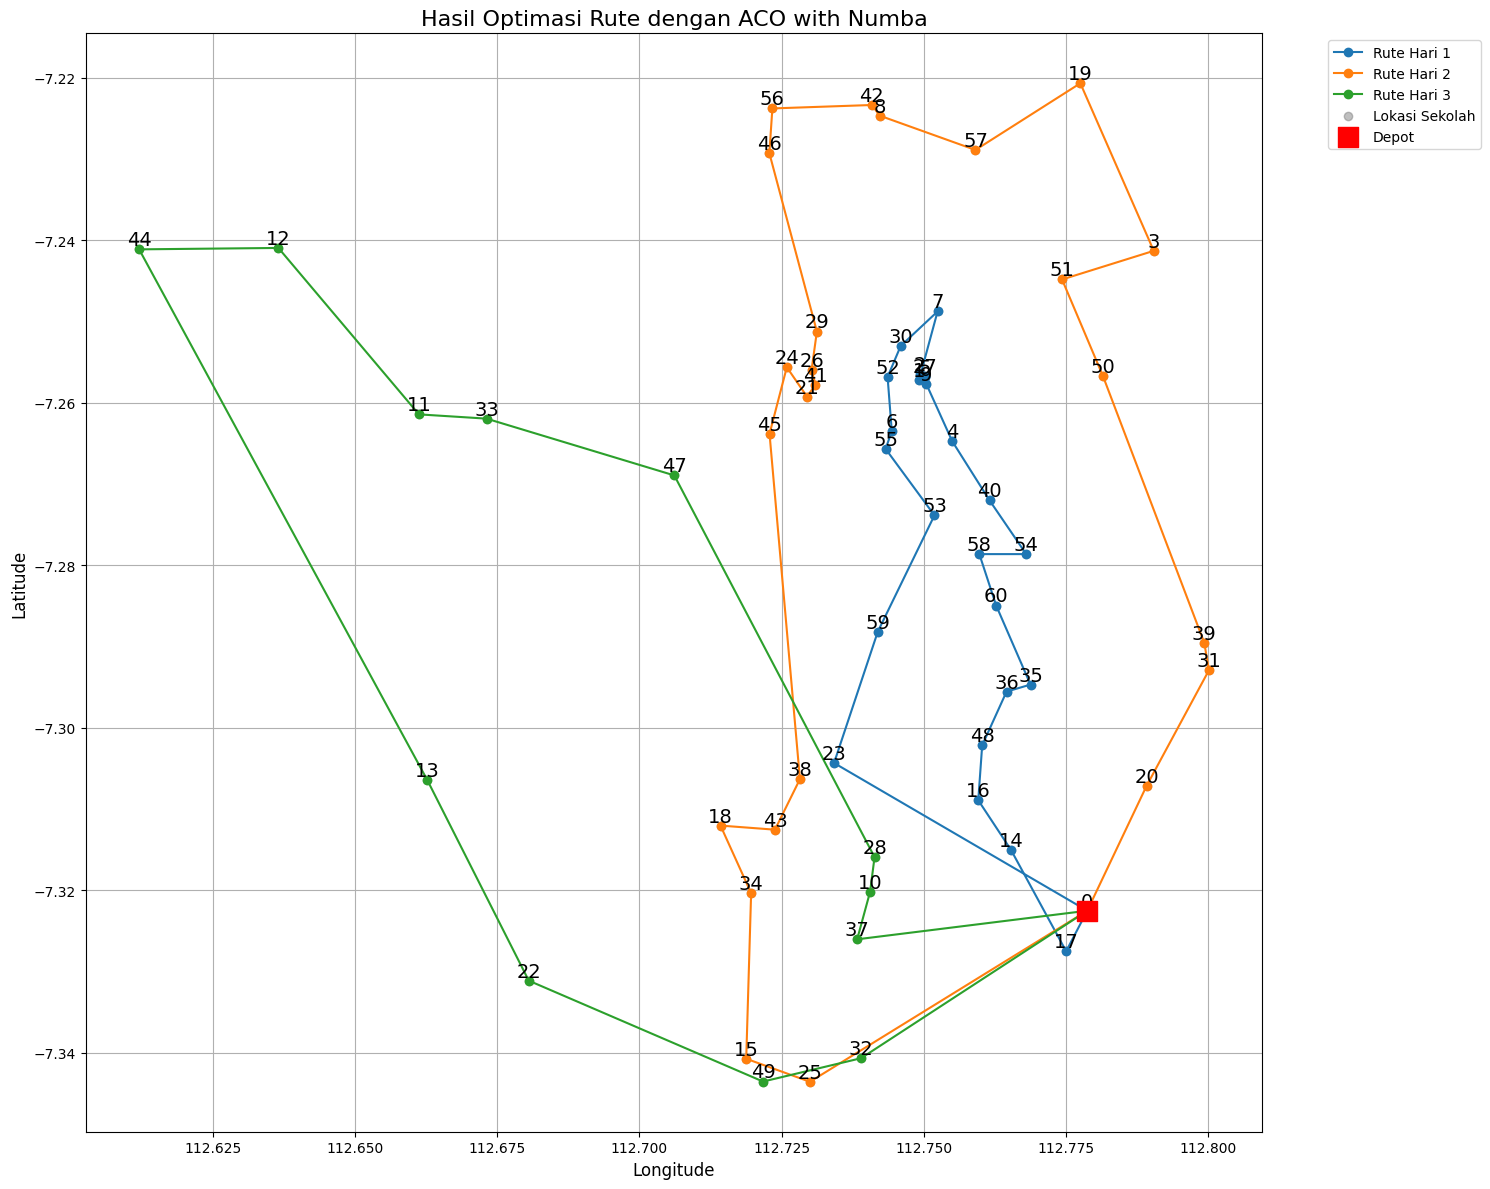

In [ ]:
# --- EKSEKUSI DAN VISUALISASI ---
print("Memulai Optimasi dengan ACO yang dipercepat Numba...")
best_routes_aco, convergence_aco= run_aco_cvrptw_numba(
    locations_to_visit=locations,
    distance_matrix=distance_matrix,
    start_times=start_times_np,
    end_times=end_times_np,
    service_times=service_times_np,
    n_ants=20,
    n_iterations=300,
    seed=46
)
print("Optimasi Selesai.")

# Panggil fungsi visualisasi dengan hasil dari ACO
visualize_solution(best_routes_aco, "ACO with Numba", all_locations_data, distance_matrix)

In [ ]:
def plot_convergence(*convergences, labels=None, max_iter=300):
    plt.figure(figsize=(10,6))
    colors = ['blue', 'green', 'orange', 'red', 'purple']

    if labels is None:
        labels = [f'Algoritma {i+1}' for i in range(len(convergences))]

    for i, conv in enumerate(convergences):
        truncated = conv[:max_iter]  # potong hingga max_iter
        plt.plot(range(len(truncated)), truncated,
                 label=labels[i], color=colors[i % len(colors)], linewidth=2)

    plt.xlabel('Iteration')
    plt.ylabel('Best Distance (km)')
    plt.title('Convergence Graph (max 100 iterations)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


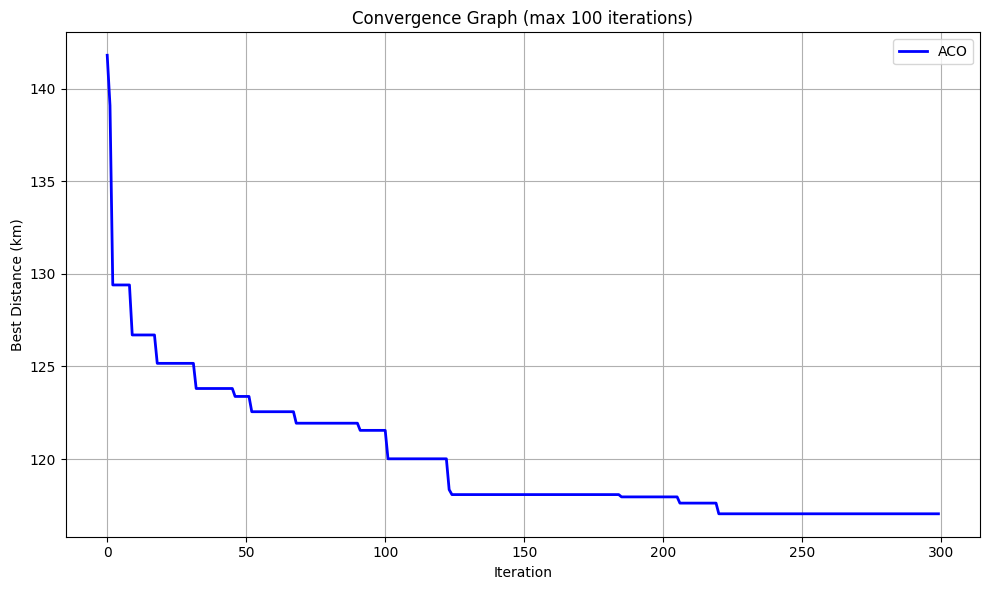

In [ ]:
plot_convergence(convergence_aco, labels=['ACO'])


Run 1...
Run 2...
Run 3...
Run 4...
Run 5...

Average distance over 5 runs: 117.14 km
Std deviation of distance: 0.32 km
Average total time: 1310.71 minutes
Std deviation of time: 0.48 minutes


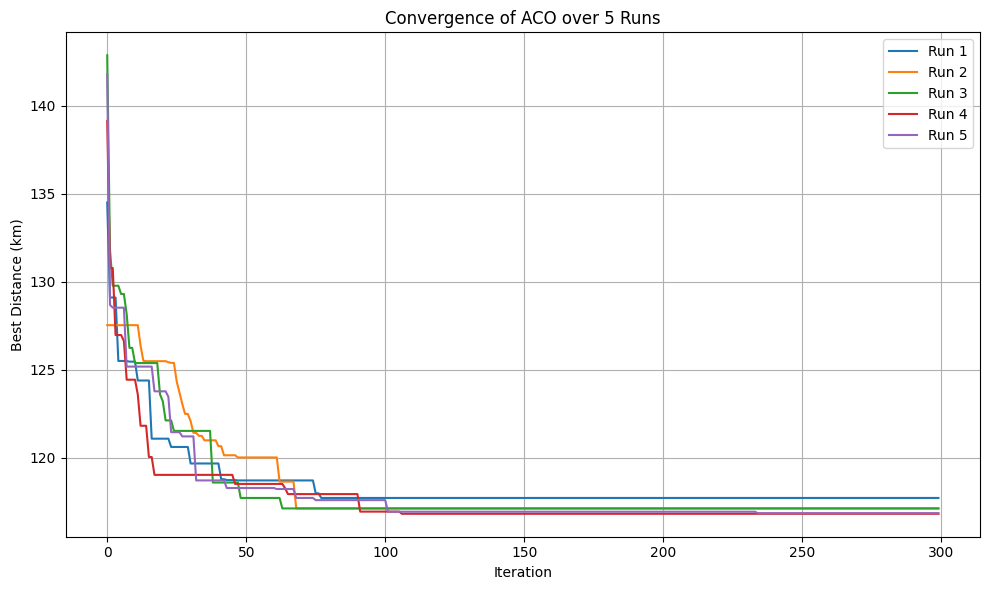

In [ ]:
def run_aco_cvrptw_numba_with_log(
    locations_to_visit, distance_matrix, start_times, end_times, service_times,
    n_ants=20, n_iterations=300, alpha=0.2, beta=6.0, rho=0.2, Q=50, seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    location_indices_np = locations_to_visit.index.to_numpy(dtype=np.int64)
    num_total_locations = len(distance_matrix)

    pheromone_matrix = np.ones((num_total_locations, num_total_locations))
    heuristic_matrix = 1.0 / (distance_matrix + 1e-10)

    best_solution_ever = []
    best_distance_ever = float('inf')
    best_duration_ever = float('inf')

    convergence_dist = []
    convergence_time = []

    for it in range(n_iterations):
        all_ant_solutions = []

        for ant in range(n_ants):
            unvisited = list(location_indices_np)
            ant_routes = []
            ant_total_distance = 0.0
            ant_total_duration = 0.0

            while unvisited:
                current_route_indices = []
                current_route_path = [0]

                while True:
                    last_loc_idx = current_route_path[-1]
                    possible_next_moves = [
                        loc for loc in unvisited
                        if evaluate_single_route_numba(
                            np.array(current_route_indices + [loc]),
                            distance_matrix, start_times, end_times, service_times
                        )[0] != np.inf
                    ]

                    if not possible_next_moves:
                        break

                    probs = np.array([
                        (pheromone_matrix[last_loc_idx, move] ** alpha) *
                        (heuristic_matrix[last_loc_idx, move] ** beta)
                        for move in possible_next_moves
                    ], dtype=np.float64)

                    probs_sum = np.sum(probs)
                    if probs_sum == 0:
                        chosen_loc = random.choice(possible_next_moves)
                    else:
                        chosen_loc = random.choices(
                            possible_next_moves,
                            weights=probs / probs_sum,
                            k=1
                        )[0]

                    current_route_indices.append(chosen_loc)
                    current_route_path.append(chosen_loc)
                    unvisited.remove(chosen_loc)

                if current_route_indices:
                    ant_routes.append(current_route_indices)
                    duration, route_dist = evaluate_single_route_numba(
                        np.array(current_route_indices),
                        distance_matrix, start_times, end_times, service_times
                    )
                    ant_total_distance += route_dist
                    ant_total_duration += duration

            all_ant_solutions.append({
                'routes': ant_routes,
                'distance': ant_total_distance,
                'duration': ant_total_duration
            })

        best_ant_in_iteration = min(all_ant_solutions, key=lambda x: x['distance'])

        if best_ant_in_iteration['distance'] < best_distance_ever:
            best_distance_ever = best_ant_in_iteration['distance']
            best_duration_ever = best_ant_in_iteration['duration']
            best_solution_ever = best_ant_in_iteration['routes']

        convergence_dist.append(best_distance_ever)
        convergence_time.append(best_duration_ever)

        pheromone_matrix *= (1 - rho)
        if best_ant_in_iteration['routes']:
            for route in best_ant_in_iteration['routes']:
                path = [0] + route + [0]
                for i in range(len(path) - 1):
                    pheromone_matrix[path[i], path[i + 1]] += Q / best_distance_ever
                    pheromone_matrix[path[i + 1], path[i]] += Q / best_distance_ever

    return best_solution_ever, convergence_dist, convergence_time


# Jalankan 5x dan kumpulkan hasil
all_runs_dist = []
all_runs_time = []
all_convergence = []

for run in range(5):
    print(f"Run {run+1}...")
    _, conv_dist, conv_time = run_aco_cvrptw_numba_with_log(
        locations_to_visit=locations,
        distance_matrix=distance_matrix,
        start_times=start_times_np,
        end_times=end_times_np,
        service_times=service_times_np,
        n_ants=20,
        n_iterations=300,
        alpha=0.5,
        beta=6.0,
        rho=0.2,
        Q=50,
        seed=42 + run  # beda seed tiap run
    )
    all_runs_dist.append(conv_dist[-1])
    all_runs_time.append(conv_time[-1])
    all_convergence.append(conv_dist)

# Hitung average & std
avg_dist = np.mean(all_runs_dist)
std_dist = np.std(all_runs_dist)
avg_time = np.mean(all_runs_time)
std_time = np.std(all_runs_time)

print(f"\nAverage distance over 5 runs: {avg_dist:.2f} km")
print(f"Std deviation of distance: {std_dist:.2f} km")
print(f"Average total time: {avg_time:.2f} minutes")
print(f"Std deviation of time: {std_time:.2f} minutes")

# Plot convergence
plt.figure(figsize=(10,6))
for i, conv in enumerate(all_convergence):
    plt.plot(conv, label=f'Run {i+1}')
plt.xlabel('Iteration')
plt.ylabel('Best Distance (km)')
plt.title('Convergence of ACO over 5 Runs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import folium
from folium.plugins import BeautifyIcon

def visualize_aco_folium(routes, df, depot_idx=0):
    depot_lat = df.at[depot_idx, 'latitude']
    depot_lon = df.at[depot_idx, 'longitude']
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=12)

    route_colors = ['blue', 'red', 'green', 'purple', 'orange', 'darkred', 'cadetblue']
    text_color = 'white'

    for cid, route in enumerate(routes):
        color = route_colors[cid % len(route_colors)]

        # Buat koordinat rute (depot + route + depot)
        full_route = [depot_idx] + route + [depot_idx]
        coords = [(df.at[idx, 'latitude'], df.at[idx, 'longitude']) for idx in full_route]

        folium.PolyLine(
            coords,
            color=color,
            weight=4,
            opacity=0.8,
            tooltip=f"Route {cid+1}"
        ).add_to(m)

        # Marker nomor
        for idx in full_route:
            lat, lon = df.at[idx, 'latitude'], df.at[idx, 'longitude']
            folium.Marker(
                location=[lat, lon],
                icon=BeautifyIcon(
                    number=int(idx),
                    icon_shape='marker',
                    border_color='black',
                    border_width=2,
                    text_color=text_color,
                    background_color=color,
                    inner_icon_style="font-weight:bold; font-size:12px;"
                )
            ).add_to(m)

    # Plot depot dengan icon star
    folium.Marker(
        location=[depot_lat, depot_lon],
        icon=folium.Icon(color='black', icon='star'),
        popup='Depot'
    ).add_to(m)

    return m


In [ ]:
# Contoh pemanggilan
folium_map = visualize_aco_folium(best_routes_aco, all_locations_data)
folium_map

# PSO + Tabu search

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from math import exp, sqrt
from geopy.distance import geodesic
from datetime import datetime, timedelta
import time
from collections import deque

# ------------------------------
# 1. Load and preprocess data
# ------------------------------
def load_and_preprocess_data():
    url = "https://docs.google.com/spreadsheets/d/1z_IKjtY56_VK5hd-2YxBjuvgwJkEko5FVPm1JXIveO4/gviz/tq?tqx=out:csv&sheet=Sheet1"
    try:
        df = pd.read_csv(url)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    # Clean and convert time data
    df['start_time_dec'] = df['start_time_dec'].str.replace(',', '.').astype(float)
    df['end_time_dec'] = df['end_time_dec'].str.replace(',', '.').astype(float)
    df['service_time_dec'] = df['service_time_dec'].str.replace(',', '.').astype(float)

    df = df.rename(columns={'please fill the place and coordinate only Place': 'Place'})
    df[['lat', 'lon']] = df['Coordinates'].str.split(',', expand=True)
    df['lat'] = pd.to_numeric(df['lat'])
    df['lon'] = pd.to_numeric(df['lon'])

    return df

# ------------------------------
# 2. Distance and Time matrices
# ------------------------------
def calculate_matrices(locations, speed_kmh=40):
    n = len(locations)
    dist_matrix = np.zeros((n, n))
    time_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            coord_i = (locations[i][0], locations[i][1])
            coord_j = (locations[j][0], locations[j][1])
            dist_km = geodesic(coord_i, coord_j).km
            dist_matrix[i][j] = dist_km
            time_matrix[i][j] = (dist_km / speed_kmh) * 60  # Convert to minutes

    return dist_matrix, time_matrix

# ------------------------------
# 3. Route utilities with Time Windows
# ------------------------------
def calculate_daily_route(route, dist_matrix, time_matrix, time_windows, service_times, depot_index=0):
    depot_open = 480  # 8:00 AM in minutes
    depot_close = 1020  # 5:00 PM in minutes
    current_time = depot_open
    day_route = [depot_index]
    total_distance = 0
    locations_visited = 0

    for i in range(len(route)):
        from_node = day_route[-1]
        to_node = route[i]

        # Calculate travel time
        travel_time = time_matrix[from_node][to_node]
        arrival_time = current_time + travel_time

        # Get location time window
        tw_start, tw_end = time_windows[to_node]
        service_time = service_times[to_node]

        # Check if we can make it back to depot after this location
        time_to_return = time_matrix[to_node][depot_index]
        latest_departure = depot_close - time_to_return

        # Check time window constraints
        if arrival_time < tw_start:
            arrival_time = tw_start  # Wait until opening
        elif arrival_time > tw_end:
            return None  # Cannot visit this location today

        # Check if we can complete service and return to depot
        departure_time = arrival_time + service_time
        if departure_time > latest_departure:
            return None  # Cannot visit this location today

        # Add this location to today's route
        day_route.append(to_node)
        current_time = departure_time
        total_distance += dist_matrix[from_node][to_node]
        locations_visited += 1

    # Return to depot
    from_node = day_route[-1]
    travel_time = time_matrix[from_node][depot_index]
    current_time += travel_time
    total_distance += dist_matrix[from_node][depot_index]
    day_route.append(depot_index)

    return {
        'route': day_route,
        'distance': total_distance,
        'end_time': current_time,
        'delivery_time': current_time - depot_open,
        'locations_visited': locations_visited
    }

def split_into_days(route, dist_matrix, time_matrix, time_windows, service_times, depot_index=0):
    remaining_locations = route.copy()
    daily_routes = []
    day_number = 1

    while remaining_locations:
        # Try to create a daily route with as many locations as possible
        for i in range(len(remaining_locations), 0, -1):
            attempt_route = remaining_locations[:i]
            daily_route = calculate_daily_route(attempt_route, dist_matrix, time_matrix,
                                              time_windows, service_times, depot_index)

            if daily_route is not None:
                daily_route['day'] = day_number
                daily_routes.append(daily_route)
                remaining_locations = remaining_locations[i:]
                day_number += 1
                break
        else:
            # If we can't fit even one location, mark as invalid
            return None

    return daily_routes

def generate_neighbors(route):
    neighbors = []
    n = len(route)

    # 2-opt neighborhood generation
    for i in range(1, n - 1):
        for j in range(i + 1, n):
            if j - i == 1:
                continue
            neighbor = route[:i] + route[i:j+1][::-1] + route[j+1:]
            neighbors.append(neighbor)

    # Random swaps for diversity
    for _ in range(min(5, n)):
        i, j = random.sample(range(1, n), 2)
        neighbor = route[:]
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        neighbors.append(neighbor)

    return neighbors

# ------------------------------
# 4. Hybrid PSO-Tabu Search Optimization
# ------------------------------
class Particle:
    def __init__(self, num_locations):
        self.position = list(range(1, num_locations))  # Exclude depot (0)
        random.shuffle(self.position)
        self.velocity = []
        self.best_position = self.position.copy()
        self.best_fitness = float('inf')
        self.best_days = float('inf')

    def update_velocity(self, global_best_position, w=0.7, c1=1.4, c2=1.4):
        max_velocity = len(self.position) / 2

        for i in range(len(self.position)):
            r1 = random.random()
            r2 = random.random()

            cognitive = c1 * r1 * (self._index_diff(self.position[i], self.best_position))
            social = c2 * r2 * (self._index_diff(self.position[i], global_best_position))

            vel = w * (len(self.velocity) > i and self.velocity[i] or 0) + cognitive + social
            vel = max(-max_velocity, min(max_velocity, vel))

            if i < len(self.velocity):
                self.velocity[i] = vel
            else:
                self.velocity.append(vel)

    def _index_diff(self, value, target_list):
        try:
            current_idx = self.position.index(value)
            target_idx = target_list.index(value)
            return target_idx - current_idx
        except ValueError:
            return 0

    def update_position(self):
        for i in range(len(self.velocity)):
            if abs(self.velocity[i]) > 0.5:
                swap_with = (i + int(round(self.velocity[i]))) % len(self.position)
                swap_with = max(0, min(len(self.position)-1, swap_with))
                if swap_with != i:
                    self.position[i], self.position[swap_with] = self.position[swap_with], self.position[i]

        self.velocity = []

def hybrid_pso_tabu_search(dist_matrix, time_matrix, time_windows, service_times,
                          max_iter=100, num_particles=20, tabu_size=10, verbose=False):
    num_locations = len(dist_matrix)
    depot_index = 0

    def evaluate_route(route):
        daily_routes = split_into_days(route, dist_matrix, time_matrix,
                                     time_windows, service_times, depot_index)
        if daily_routes is None:
            return float('inf'), float('inf'), None

        total_distance = sum(day['distance'] for day in daily_routes)
        total_days = len(daily_routes)
        total_minutes = sum(day['delivery_time'] for day in daily_routes)
        return total_distance, total_days, total_minutes, daily_routes

    # Initialize particles
    particles = [Particle(num_locations) for _ in range(num_particles)]
    global_best_position = None
    global_best_fitness = float('inf')
    global_best_days = float('inf')
    global_best_minutes = float('inf')
    global_best_daily_routes = None

    # Tabu list
    tabu_list = deque(maxlen=tabu_size)

    # Initialize with nearest neighbor
    def nearest_neighbor_route(start_index=0):
        unvisited = set(range(num_locations)) - {start_index}
        route = [start_index]

        while unvisited:
            last = route[-1]
            next_node = min(unvisited, key=lambda x: dist_matrix[last][x])
            route.append(next_node)
            unvisited.remove(next_node)
        return route[1:]  # Return without depot

    nn_route = nearest_neighbor_route()
    nn_fitness, nn_days, nn_minutes, nn_daily_routes = evaluate_route(nn_route)
    if nn_fitness < float('inf'):
        global_best_position = nn_route
        global_best_fitness = nn_fitness
        global_best_days = nn_days
        global_best_minutes = nn_minutes
        global_best_daily_routes = nn_daily_routes

    # Convergence tracking
    convergence_pso_tabu = []

    # Main optimization loop
    for iteration in range(max_iter):
        w = 0.7  # Fixed inertia weight

        for particle in particles:
            fitness, days, minutes, daily_routes = evaluate_route(particle.position)

            if fitness < particle.best_fitness:
                particle.best_fitness = fitness
                particle.best_days = days
                particle.best_minutes = minutes
                particle.best_position = particle.position.copy()

                if fitness < global_best_fitness:
                    global_best_position = particle.position.copy()
                    global_best_fitness = fitness
                    global_best_days = days
                    global_best_minutes = minutes
                    global_best_daily_routes = daily_routes

            particle.update_velocity(global_best_position, w)
            particle.update_position()

        # Tabu Search phase
        if iteration % 5 == 0:
            current_route = global_best_position.copy()
            improved = True
            local_iter = 0

            while improved and local_iter < 20:
                improved = False
                neighbors = generate_neighbors(current_route)
                best_neighbor = None
                best_neighbor_fitness = float('inf')

                for neighbor in neighbors:
                    if tuple(neighbor) not in tabu_list:
                        fitness, days, minutes, _ = evaluate_route(neighbor)

                        if fitness < best_neighbor_fitness:
                            best_neighbor = neighbor
                            best_neighbor_fitness = fitness

                if best_neighbor is not None and best_neighbor_fitness < global_best_fitness:
                    current_route = best_neighbor
                    tabu_list.append(tuple(best_neighbor))
                    improved = True
                    local_iter += 1

                    # Update global best
                    fitness, days, minutes, daily_routes = evaluate_route(current_route)
                    global_best_position = current_route.copy()
                    global_best_fitness = fitness
                    global_best_days = days
                    global_best_minutes = minutes
                    global_best_daily_routes = daily_routes

        convergence_pso_tabu.append(global_best_fitness)

        if verbose and iteration % 10 == 0:
            if global_best_daily_routes is not None:
                print(f"Iteration {iteration}: Best Distance = {global_best_fitness:.2f} km | "
                      f"Total Time: {global_best_minutes} minutes | Days Required = {global_best_days}")
            else:
                print(f"Iteration {iteration}: Best Distance = {global_best_fitness:.2f} km | "
                      f"Total Time: N/A minutes | Days Required = N/A")

    return (global_best_position, global_best_fitness, global_best_days,
            global_best_daily_routes, convergence_pso_tabu)


# ------------------------------
# 5. Visualization
# ------------------------------
def format_minutes_to_time(minutes):
    hours = int(minutes // 60)
    mins = int(minutes % 60)
    return f"{hours:02d}:{mins:02d}"

def visualize_all_routes(df, daily_routes, title):
    plt.figure(figsize=(14, 10))
    colors = plt.cm.tab20.colors
    latlon = df[['lat', 'lon']].values

    # Plot all locations
    plt.scatter(latlon[:, 1], latlon[:, 0], c='gray', alpha=0.3, s=30, label='Unvisited')
    plt.scatter(latlon[0][1], latlon[0][0], c='red', marker='X', s=200, label='Depot')

    # Plot each day's route
    for day_data in daily_routes:
        route = day_data['route']
        day = day_data['day']
        color = colors[(day-1) % len(colors)]

        # Plot route lines
        route_lons = [latlon[i][1] for i in route]
        route_lats = [latlon[i][0] for i in route]
        plt.plot(route_lons, route_lats, marker='o', linestyle='-',
                markersize=6, linewidth=2.5, color=color,
                label=f'Day {day} ({day_data["locations_visited"]} locs, {day_data["distance"]:.1f} km)')

        # Plot visited locations
        plt.scatter([latlon[i][1] for i in route[1:-1]],
                   [latlon[i][0] for i in route[1:-1]],
                   c=color, s=80, edgecolors='k', linewidths=0.5)

    # Annotations
    for i in range(len(latlon)):
        plt.annotate(str(i), (latlon[i][1], latlon[i][0]),
                    textcoords="offset points", xytext=(0,3), ha='center',
                    fontsize=14, alpha=0.8)

    plt.title(title, fontsize=16)
    plt.xlabel('Longitude', fontsize=10)
    plt.ylabel('Latitude', fontsize=10)
    plt.grid(True, alpha=0.2)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

def print_daily_schedule(daily_routes, df):
    print("\n=== DAILY SCHEDULE ===")
    for day in daily_routes:
        print(f"\nDay {day['day']}:")
        print(f"Locations visited: {day['locations_visited']}")
        print(f"Route distance: {day['distance']:.2f} km")
        print(f"Departure: {format_minutes_to_time(480)}")
        print(f"Return: {format_minutes_to_time(day['end_time'])}")
        print("Route:")
        print(" → ".join(df['Place'].iloc[i] for i in day['route']))



Optimization started at: 2025-06-25 05:30:04

--- PSO+Tabu Search Optimization ---
Iteration 0: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 10: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 20: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 30: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 40: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 50: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 60: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 70: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteration 80: Best Distance = 116.60 km | Total Time: 1339.0323962118434 minutes | Days Required = 3
Iteratio

/tmp/ipython-input-23-2881308442.py:353: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([latlon[i][1] for i in route[1:-1]],


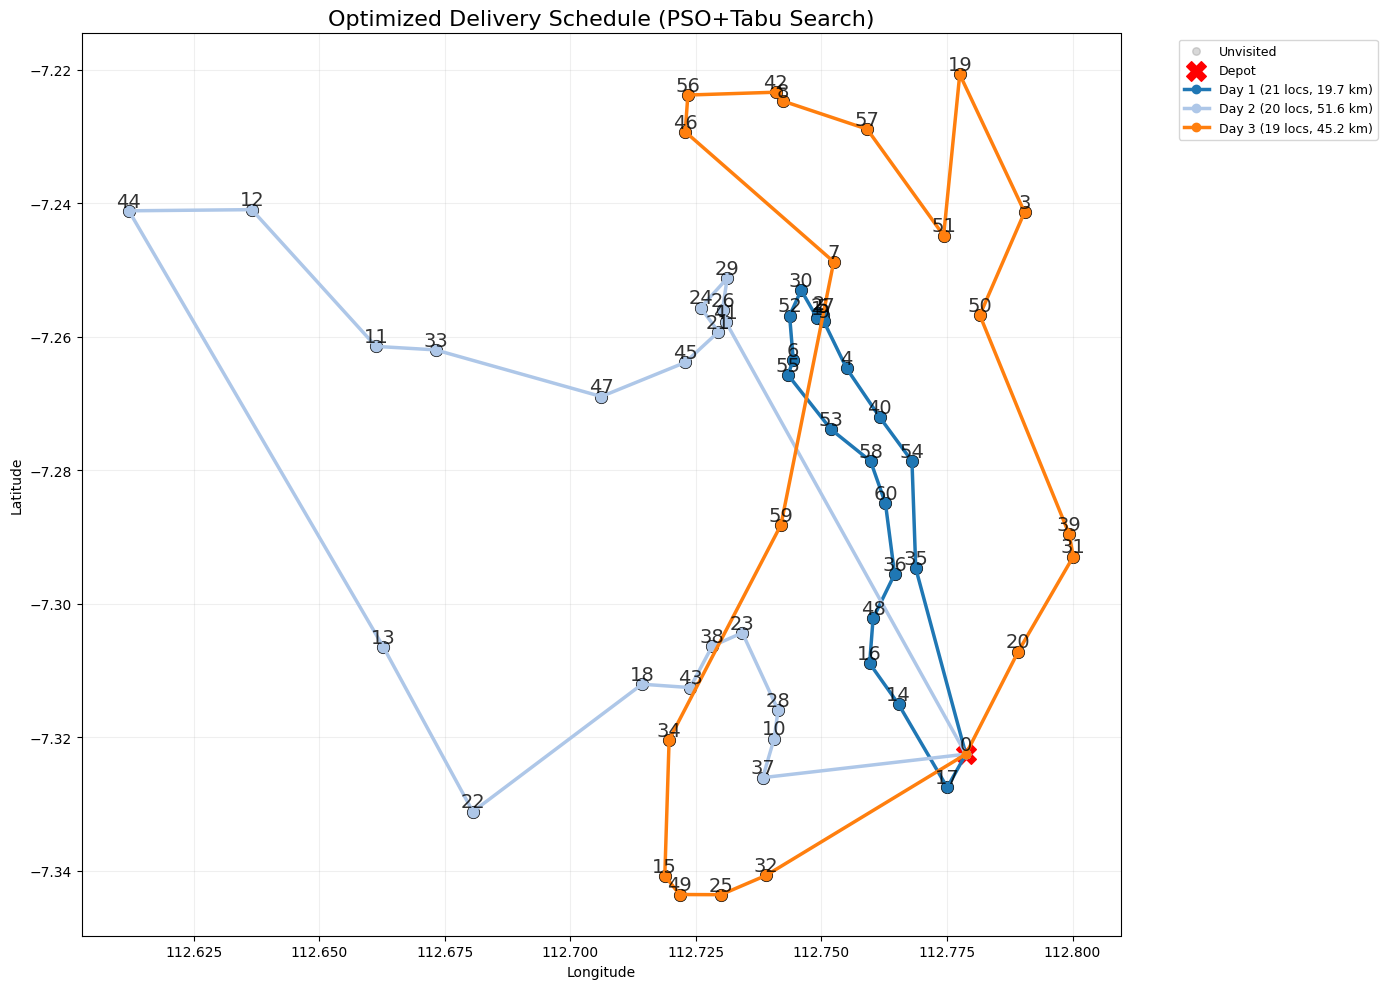


Total Program Execution Time: 147.29 seconds


In [ ]:
# ------------------------------
# 6. Main Execution
# ------------------------------
if __name__ == "__main__":
    start_time = time.time()
    print(f"\nOptimization started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    df = load_and_preprocess_data()
    if df is None:
        print("Error: Data loading or preprocessing failed. Exiting.")
        exit()

    # Convert time windows to minutes
    time_windows = df[['start_time_dec', 'end_time_dec']].values * 60
    service_times = df['service_time_dec'].values * 60

    # Calculate matrices
    dist_matrix, time_matrix = calculate_matrices(df[['lat', 'lon']].values)

    # Run optimization
    print("\n--- PSO+Tabu Search Optimization ---")
    best_route, best_distance, best_days, daily_routes, convergence_pso_tabu = hybrid_pso_tabu_search(
        dist_matrix, time_matrix, time_windows, service_times, verbose=True)

    if best_distance < float('inf'):
        # Calculate total time in minutes and convert to hours
        total_minutes = sum(day['delivery_time'] for day in daily_routes)
        total_hours = total_minutes / 60

        print("\n=== OPTIMIZATION RESULTS ===")
        print(f"Total Distance: {best_distance:.2f} km")
        print(f"Days Required: {best_days}")
        print(f"Total Delivery Time: {total_minutes} minutes ({total_hours:.2f} hours)")

        print("\n=== DAILY SCHEDULE ===")
        for day in daily_routes:
            # Convert delivery time to hours for display
            delivery_hours = day['delivery_time'] / 60

            print(f"\nDay {day['day']}:")
            print(f"Locations visited: {day['locations_visited']}")
            print(f"Route distance: {day['distance']:.2f} km")
            print(f"Departure: {format_minutes_to_time(480)}")
            print(f"Return: {format_minutes_to_time(day['end_time'])}")
            print(f"Delivery Time: {day['delivery_time']} minutes ({delivery_hours:.2f} hours)")
            print("Route:")
            print(" → ".join(df['Place'].iloc[i] for i in day['route']))

        visualize_all_routes(df, daily_routes, "Optimized Delivery Schedule (PSO+Tabu Search)")
    else:
        print("\nNo valid solution found within time constraints")

    # Print total execution time
    total_runtime = time.time() - start_time
    print(f"\nTotal Program Execution Time: {total_runtime:.2f} seconds")

In [ ]:
import folium
from folium.plugins import BeautifyIcon

def visualize_folium_routes(df, daily_routes, map_title="Optimized Routes (PSO + Tabu Search)"):
    depot_lat = df.at[0, 'lat']
    depot_lon = df.at[0, 'lon']
    m = folium.Map(location=[depot_lat, depot_lon], zoom_start=12, tiles='OpenStreetMap')

    route_colors = ['blue','red', 'green', 'orange', 'purple', 'darkred', 'lightblue', 'lightgreen']

    for day_data in daily_routes:
        route = day_data['route']
        day = day_data['day']
        color = route_colors[(day - 1) % len(route_colors)]

        coords = [(df.at[idx, 'lat'], df.at[idx, 'lon']) for idx in route]
        folium.PolyLine(
            coords,
            color=color,
            weight=4,
            opacity=0.8,
            tooltip=f"Day {day} ({day_data['distance']:.2f} km)"
        ).add_to(m)

        # Add markers
        for idx in route:
            lat = df.at[idx, 'lat']
            lon = df.at[idx, 'lon']
            folium.Marker(
                location=[lat, lon],
                icon=BeautifyIcon(
                    number=int(idx),
                    icon_shape='marker',
                    border_color='black',
                    border_width=2,
                    text_color='white',
                    background_color=color,
                    inner_icon_style="font-weight:bold;font-size:10px;"
                ),
                tooltip=df.at[idx, 'Place']
            ).add_to(m)

    # Add depot marker
    folium.Marker(
        location=[depot_lat, depot_lon],
        icon=folium.Icon(color='black', icon='star'),
        popup='Depot / LBB'
    ).add_to(m)

    print(f"✅ {map_title} successfully generated.")
    return m


In [ ]:
# Visualisasi dengan folium
folium_map = visualize_folium_routes(df, daily_routes)
folium_map  # Tampilkan di notebook

✅ Optimized Routes (PSO + Tabu Search) successfully generated.


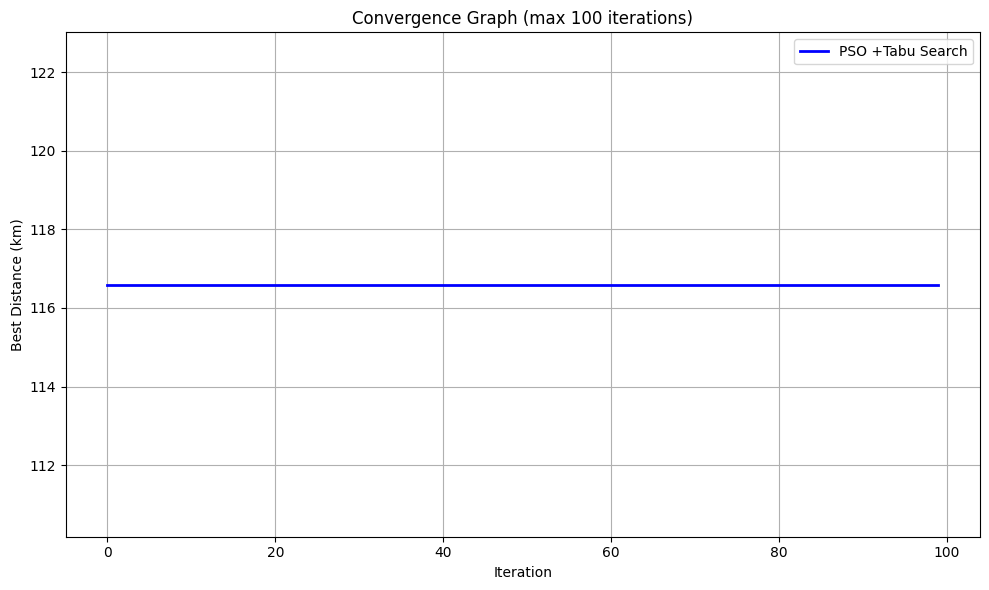

In [ ]:
plot_convergence(convergence_pso_tabu, labels=['PSO +Tabu Search'])

# 2opt + SA

In [ ]:
import pandas as pd
import numpy as np
import math
import random
from sklearn.cluster import KMeans
import time
import matplotlib.pyplot as plt

In [ ]:
sheet_id = "1z_IKjtY56_VK5hd-2YxBjuvgwJkEko5FVPm1JXIveO4"
sheet_name = "Sheet1"

csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(csv_url, decimal=',')

print(df.head())

   No                  Place                              Coordinates  \
0   1        LBB Nurul Fikri   -7.322512479985737, 112.77876084047776   
1   2  SMA Negeri 1 Surabaya   -7.257242833292316, 112.74916690952959   
2   3  SMA Negeri 2 Surabaya   -7.256427756879855, 112.74938016427122   
3   4  SMA Negeri 3 Surabaya  -7.2413221513779344, 112.79045296382363   
4   5  SMA Negeri 4 Surabaya   -7.264745426779094, 112.75501295696357   

  Start_time End_time  Service_Time  start_time_dec  end_time_dec  \
0       8:00    17:00             0             8.0         17.00   
1       6:30    15:00            25             6.5         15.00   
2       6:30    17:00            20             6.5         17.00   
3       6:30    15:15            18             6.5         15.25   
4       6:30    16:00            21             6.5         16.00   

   service_time_dec  
0              0.00  
1              0.42  
2              0.33  
3              0.30  
4              0.35  


In [ ]:
df.head()

,No,Place,Coordinates,Start_time,End_time,Service_Time,start_time_dec,end_time_dec,service_time_dec
0,1,LBB Nurul Fikri,"-7.322512479985737, 112.77876084047776",8:00,17:00,0,8.0,17.00,0.00
1,2,SMA Negeri 1 Surabaya,"-7.257242833292316, 112.74916690952959",6:30,15:00,25,6.5,15.00,0.42
2,3,SMA Negeri 2 Surabaya,"-7.256427756879855, 112.74938016427122",6:30,17:00,20,6.5,17.00,0.33
3,4,SMA Negeri 3 Surabaya,"-7.2413221513779344, 112.79045296382363",6:30,15:15,18,6.5,15.25,0.30
4,5,SMA Negeri 4 Surabaya,"-7.264745426779094, 112.75501295696357",6:30,16:00,21,6.5,16.00,0.35


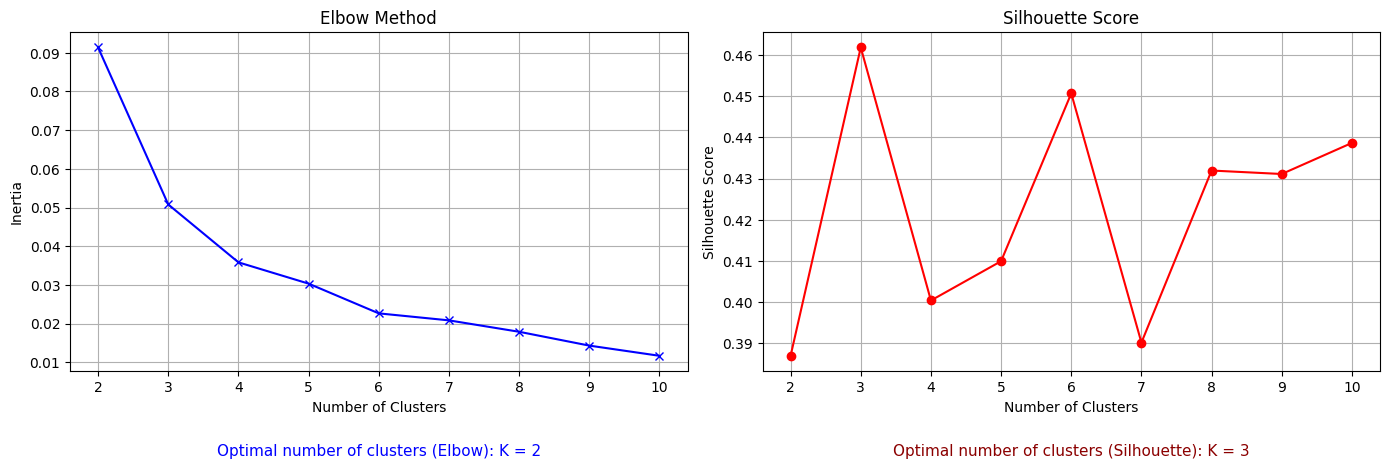


 Best Optimal Cluster : 3.


In [ ]:
from sklearn.metrics import silhouette_score

## split Coordinate into Latitude & Longitude
df[['Latitude', 'Longitude']] = ( df['Coordinates'].str.split(r',\s*', expand=True).astype(float))

# Determine clustering using the Elbow and Silhouette methods
coords = df.iloc[1:][['Latitude', 'Longitude']].copy()

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(coords)
    labels = kmeans.labels_
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(coords, labels))


# Elbow Score
inertia_diffs = np.diff(inertias)
optimal_k_elbow = K_range[np.argmax(inertia_diffs * -1)]

# Silhoutte Score
optimal_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Elbow
ax1.plot(K_range, inertias, 'bx-', label='Inertia')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)
ax1.text(0.5, -0.25, f"Optimal number of clusters (Elbow): K = {optimal_k_elbow}",
         transform=ax1.transAxes, ha='center', fontsize=11, color='blue')

# Plot Silhoutte
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
ax2.grid(True)
ax2.text(0.5, -0.25, f"Optimal number of clusters (Silhouette): K = {optimal_k_silhouette}",
         transform=ax2.transAxes, ha='center', fontsize=11, color='darkred')

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()

print(f"\n Best Optimal Cluster : {optimal_k_silhouette}.")

In [ ]:
# Clustering

# Mark the first row as the depot
df['is_depot'] = False
df.loc[df.index[0], 'is_depot'] = True

coords = df[['Latitude', 'Longitude']].values # coordinate from dataset

# K-Means clustering
k = optimal_k_silhouette # from optimal clustering
kmeans = KMeans(n_clusters=k, random_state=42).fit(coords)
df['cluster'] = kmeans.labels_

# Find depot index & name
depot_idx  = df.index[df['is_depot']].tolist()[0]
depot_name = df.loc[depot_idx, 'Place']

for cid in sorted(df['cluster'].unique()):
    # get member indices (exclude depot)
    member_idx = df.loc[
        (df['cluster'] == cid) & (~df['is_depot']),
        :
    ].index.tolist()

    # build route indices and names
    route_idx    = [depot_idx] + member_idx + [depot_idx]
    route_places = [depot_name] + df.loc[member_idx, 'Place'].tolist() + [depot_name]

    print("Clustering Results")
    print(f"\nRoute {cid} route indices: {route_idx}")
    print(f"Route{cid} route places : {route_places}")

Clustering Results

Route 0 route indices: [0, 11, 12, 13, 22, 33, 44, 47, 0]
Route0 route places : ['LBB Nurul Fikri', 'SMA Negeri 11 Surabaya', 'SMA Negeri 12 Surabaya', 'SMA Negeri 13 Surabaya', 'SMA Negeri 22 Surabaya', 'SMK Negeri 13 Surabaya', 'SMA Al-Azhar Surabaya', 'SMK Siang Surabaya', 'LBB Nurul Fikri']
Clustering Results

Route 1 route indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 19, 21, 24, 26, 27, 29, 30, 40, 41, 42, 45, 46, 50, 51, 52, 53, 54, 55, 56, 57, 58, 0]
Route1 route places : ['LBB Nurul Fikri', 'SMA Negeri 1 Surabaya', 'SMA Negeri 2 Surabaya', 'SMA Negeri 3 Surabaya', 'SMA Negeri 4 Surabaya', 'SMA Negeri 5 Surabaya', 'SMA Negeri 6 Surabaya', 'SMA Negeri 7 Surabaya', 'SMA Negeri 8 Surabaya', 'SMA Negeri 9 Surabaya', 'SMA Negeri 19 Surabaya', 'SMA Negeri 21 Surabaya', 'SMK Negeri 2 Surabaya', 'SMK Negeri 4 Surabaya', 'SMK Negeri 5 Surabaya', 'SMK Negeri 7 Surabaya', 'SMK Negeri 8 Surabaya', 'SMK Pariwisata Satya Widya', 'SMA Advent Anjasmoro Surabaya', 'SMA Al-Irsyad S

In [ ]:
# Identity depot
depot_idx  = df.index[df['is_depot']].tolist()[0]
depot_name = df.loc[depot_idx, 'Place']
speed_kmph = 40.0

# Haversine distance (km)
coords = df[['Latitude','Longitude']].values
def haversine(a, b, R=6371):
    lat1, lon1 = map(math.radians, a)
    lat2, lon2 = map(math.radians, b)
    dlat, dlon = lat2-lat1, lon2-lon1
    h = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return 2 * R * math.atan2(math.sqrt(h), math.sqrt(1-h))

# Route Distance
def route_distance(route):
    return sum(
        haversine(coords[route[i]], coords[route[i+1]])
        for i in range(len(route)-1)
    )

# 2-Opt

def two_opt(route):
    def swap(r, i, j):
        return r[:i] + list(reversed(r[i:j])) + r[j:]
    best = route[:]
    improved = True
    while improved:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                if j == i+1:
                    continue
                cand = swap(best, i, j)
                if route_distance(cand) < route_distance(best):
                    best, improved = cand, True
        route = best
    return best

"""
def two_opt(route, max_iters=1000, max_no_improve=200):
    def swap(r, i, j):
        return r[:i] + list(reversed(r[i:j])) + r[j:]

    best = route[:]
    no_improve = 0
    iters = 0

    while iters < max_iters and no_improve < max_no_improve:
        improved = False
        iters += 1

        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                if j == i+1:
                    continue
                cand = swap(best, i, j)
                if route_distance(cand) < route_distance(best):
                    best = cand
                    improved = True
                    no_improve = 0
                    break
            if improved:
                break

        if not improved:
            no_improve += 1

    return best
"""

# Simulated Annealing
"""
def simulated_annealing(route, T0=1.0, alpha=0.995, Tmin=1e-3, iter_per_T=100):
    current, best = route[:], route[:]
    curr_cost = route_distance(current)
    best_cost = curr_cost
    T = T0
    while T > Tmin:
        for _ in range(iter_per_T):
            i, j = sorted(random.sample(range(1, len(current)-1), 2))
            cand = current[:i] + list(reversed(current[i:j])) + current[j:]
            cand_cost = route_distance(cand)
            delta = cand_cost - curr_cost
            if delta < 0 or random.random() < math.exp(-delta/T):
                current, curr_cost = cand, cand_cost
                if curr_cost < best_cost:
                    best, best_cost = cand[:], cand_cost
        T *= alpha
    return best
"""
def simulated_annealing(route,
                        T0=3.0,
                        alpha=0.995,
                        Tmin=1e-3,
                        iter_per_T=100,
                        return_history=False):

    current = route[:]
    best = route[:]
    curr_cost = route_distance(current)
    best_cost = curr_cost

    T = T0
    history = []

    while T > Tmin:
        for _ in range(iter_per_T):
            i, j = sorted(random.sample(range(1, len(current) - 1), 2)) #2-Opt
            cand = current[:i] + list(reversed(current[i:j])) + current[j:]
            cand_cost = route_distance(cand)
            delta = cand_cost - curr_cost

            if delta < 0 or random.random() < math.exp(-delta / T):
                current, curr_cost = cand, cand_cost
                if curr_cost < best_cost:
                    best, best_cost = current[:], curr_cost

            if return_history:
                history.append(best_cost)

        T *= alpha

    if return_history:
        return best, history
    else:
        return best

# Time-window validation
def validate_time_windows(route):
    time = 0.0
    prev = route[0]
    violations = []
    for idx in route[1:]:
        travel  = haversine(coords[prev], coords[idx]) / speed_kmph
        arrival = time + travel

        # cast to float
        start = float(df.at[idx, 'start_time_dec'])
        end   = float(df.at[idx, 'end_time_dec'])

        if arrival < start:
            arrival = start
        if arrival > end:
            violations.append((df.at[idx,'Place'], arrival, (start, end)))

        time = arrival + float(df.at[idx, 'service_time_dec'])
        prev = idx

    if violations:
        print("Time-window violations:")
        for p,a,(s,e) in violations:
            print(f"   - {p}: arrival {a:.2f}h window [{s:.2f}-{e:.2f}]")
    else:
        print("No time-window violations.")

In [ ]:
def run_once(show_details=False):
    start = time.time()
    total_dist, total_time = 0.0, 0.0

    histories, distances, routes = {}, {}, {}
    combined_history = []

    for cid in sorted(df['cluster'].unique()):
        members = df.index[(df['cluster']==cid) & (~df['is_depot'])].tolist()
        if not members:
            continue

        # rute awal & 2-Opt
        route0    = [depot_idx] + members + [depot_idx]
        route_2op = two_opt(route0)
        #route_2op = two_opt(route0, max_iters=1000, max_no_improve=200)

        # Refinement SA + ambil history best_cost
        best_route, history = simulated_annealing(route_2op, return_history=True)
        histories[cid] = history
        #combined_history.extend(history)
        routes[cid]   = best_route

        # Hitung jarak
        d = route_distance(best_route)
        distances[cid] = d
        total_dist += d

        # Hitung waktu (menit)
        t_h, prev = 0.0, best_route[0]
        for idx in best_route[1:]:
            t_h += haversine(coords[prev], coords[idx]) / speed_kmph
            t_h += df.at[idx, 'service_time_dec']
            prev = idx
        total_time += t_h * 60


        if show_details:
            places = df.loc[best_route, 'Place'].tolist()
            print(f"\nRoute {cid+1}")
            print("Route: ", " → ".join(places))
            print(f"Distance:   {d:.2f} km")
            print(f"Total Time: {t_h*60:.2f} minutes")
            print("Validation:")
            validate_time_windows(best_route)

    if show_details:
        print("\n" + "="*55)
        print(f"Total Distance for All Clusters: {total_dist:.2f} km")
        print(f"Total Time for All Clusters:     {total_time:.2f} minutes")
        print("="*55 + "\n")

    H = np.vstack(list(histories.values()))  # shape = (n_cluster, M)
    total_history = H.sum(axis=0)            # shape = (M,)

    elapsed = time.time() - start
    return total_dist, total_time, histories, distances, total_history, routes

dist0, time0, hists0, dists0, hist_all0, routes0 = run_once(show_details=True)



Route 1
Route:  LBB Nurul Fikri → SMA Negeri 22 Surabaya → SMA Negeri 13 Surabaya → SMA Al-Azhar Surabaya → SMA Negeri 12 Surabaya → SMA Negeri 11 Surabaya → SMK Negeri 13 Surabaya → SMK Siang Surabaya → LBB Nurul Fikri
Distance:   44.68 km
Total Time: 196.62 minutes
Validation:
No time-window violations.

Route 2
Route:  LBB Nurul Fikri → SMA Kristen Petra 2 Surabaya → SMK Pariwisata Satya Widya → SMA Negeri 4 Surabaya → SMA Negeri 9 Surabaya → SMA Negeri 5 Surabaya → SMK Negeri 5 Surabaya → SMA Negeri 1 Surabaya → SMA Negeri 2 Surabaya → SMK Negeri 8 Surabaya → SMA Negeri 7 Surabaya → SMA PGRI 3 Surabaya → SMA HIDAYATUL UMMAH → SMA Negeri 3 Surabaya → SMA Negeri 19 Surabaya → SMA YP 17 SURABAYA → SMA Negeri 8 Surabaya → SMA Al-Irsyad Surabaya → SMA Hang Tuah - 4 Surabaya → SMA Hang Tuah 1 Surabaya → SMK Negeri 7 Surabaya → SMK Negeri 4 Surabaya → SMK Negeri 2 Surabaya → SMK Antartika Surabaya → SMA Negeri 21 Surabaya → SMA Advent Anjasmoro Surabaya → SMA Trimurti → SMA Negeri 6 Sura

In [ ]:
runs = [run_once(show_details=False) for _ in range(5)]

distances = [r[0] for r in runs]
times_min  = [r[1] for r in runs]
days       = [len(r[5]) for r in runs]

avg_dist_per_day = [d / nd for d, nd in zip(distances, days)]
avg_time_per_day = [t / nd for t, nd in zip(times_min, days)]

summary = {
    'Metric': [
        'Total distance',
        'Total time',
        'Number of routes (days)',
        'Average distance per day',
        'Average time per day'
    ],
    'Value': [
        f"{np.mean(distances):.2f} ± {np.std(distances):.2f} km",
        f"{np.mean(times_min):.2f} ± {np.std(times_min):.2f} minutes",
        f"{np.mean(days):.0f} ± {np.std(days):.0f}",
        f"{np.mean(avg_dist_per_day):.2f} ± {np.std(avg_dist_per_day):.2f} km",
        f"{np.mean(avg_time_per_day):.2f} ± {np.std(avg_time_per_day):.2f} minutes"
    ]
}

import pandas as pd
print(pd.DataFrame(summary).to_markdown(index=False))

| Metric                   | Value                  |
|:-------------------------|:-----------------------|
| Total distance           | 120.60 ± 0.05 km       |
| Total time               | 1313.70 ± 0.07 minutes |
| Number of routes (days)  | 3 ± 0                  |
| Average distance per day | 40.20 ± 0.02 km        |
| Average time per day     | 437.90 ± 0.02 minutes  |


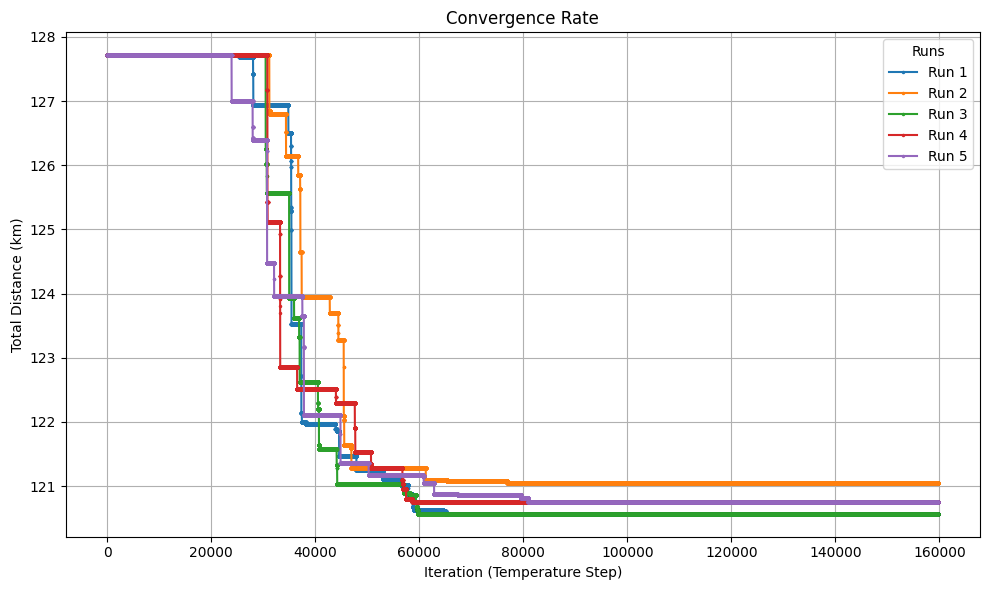

In [ ]:
# ambil history total_distance tiap run (position ke-4 di return)
runs       = [run_once(False) for _ in range(5)]
conv_hists = [r[4] for r in runs]

plt.figure(figsize=(10,6))
for i, hist in enumerate(conv_hists, start=1):
    # kalau mau x-axis = suhu-step:
    x = np.arange(len(hist))
    # kalau mau x-axis = total swap:
    #x = np.arange(len(hist)) * iter_per_T

    plt.plot(x, hist, marker='.', markersize=3, label=f'Run {i}')

plt.title("Convergence Rate")
plt.xlabel("Iteration (Temperature Step)")
plt.ylabel("Total Distance (km)")
plt.grid(True)
plt.legend(title="Runs")
plt.tight_layout()
plt.show()

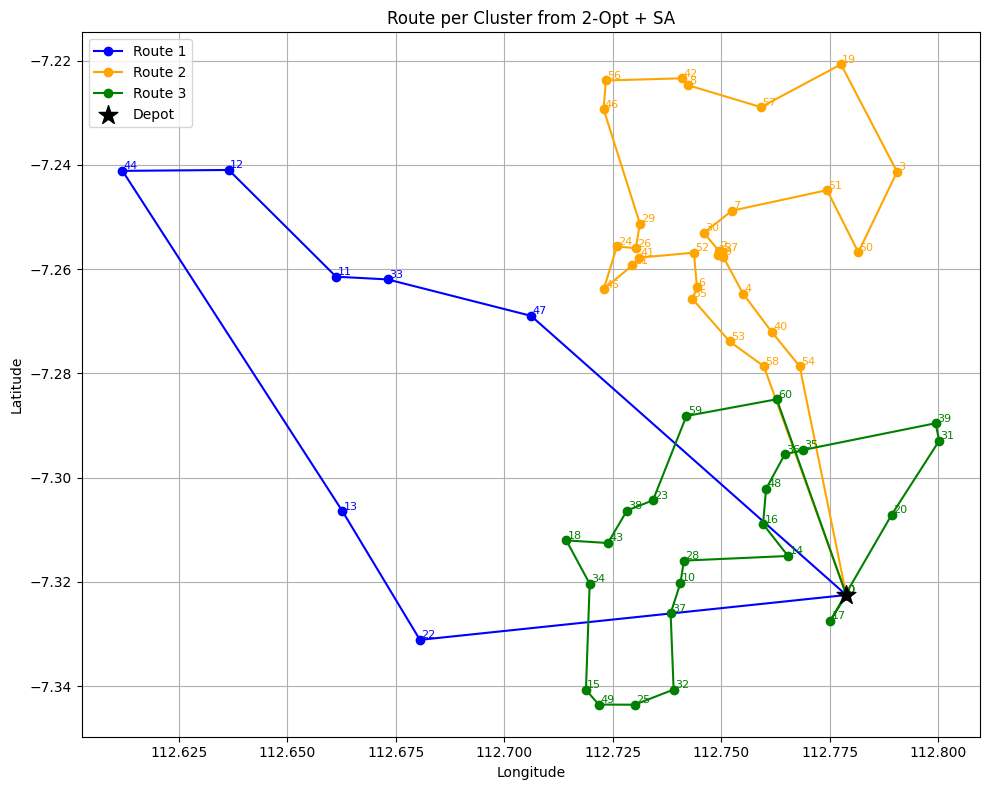

In [ ]:
colors = ['blue', 'orange', 'green', 'purple', 'cyan']
plt.figure(figsize=(10,8))

clusters = list(routes0.keys())

for cid in clusters:
    route = routes0[cid]
    lons  = df.loc[route, 'Longitude']
    lats  = df.loc[route, 'Latitude']

    # plot garis
    plt.plot(lons, lats, '-o',
             color=colors[cid % len(colors)],
             label=f'Route {cid+1}',
             markersize=6, linewidth=1.5)

    # label index
    for lon, lat, idx in zip(lons, lats, route):
        plt.text(lon+0.0003, lat+0.0003, str(idx),
                 fontsize=8, color=colors[cid % len(colors)])

# plot depot
depot_lon = df.at[depot_idx, 'Longitude']
depot_lat = df.at[depot_idx, 'Latitude']
plt.scatter([depot_lon], [depot_lat],
            marker='*', s=200, c='k', zorder=10, label='Depot')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Route per Cluster from 2-Opt + SA')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import folium
from folium.plugins import BeautifyIcon

depot_lat = df.at[depot_idx, 'Latitude']
depot_lon = df.at[depot_idx, 'Longitude']
m = folium.Map(location=[depot_lat, depot_lon], zoom_start=12)

route_colors = ['blue', 'red', 'green']
text_color = 'white'

# Plot setiap route
for cid, route in routes0.items():
    color = route_colors[cid % len(route_colors)]
    # garis rute
    coords = [(df.at[idx,'Latitude'], df.at[idx,'Longitude']) for idx in route]
    folium.PolyLine(
        coords,
        color=color,
        weight=4,
        opacity=0.8,
        tooltip=f"Route {cid+1}"
    ).add_to(m)

    # nomor marker
    for idx in route:
        lat, lon = df.at[idx,'Latitude'], df.at[idx,'Longitude']
        folium.Marker(
            location=[lat, lon],
            icon=BeautifyIcon(
                number=idx,               # tampilkan index sebagai angka
                icon_shape='marker',       # bentuk pin
                border_color='black',      # garis pinggir hitam
                border_width=2,
                text_color=text_color,     # teks hitam
                background_color=color,    # latar sesuai rute
                inner_icon_style="font-weight:bold; font-size:12px;"
            )
        ).add_to(m)

# Plot depot
folium.Marker(
    location=[depot_lat, depot_lon],
    icon=folium.Icon(color='black', icon='star'),
    popup='LBB Nurul Fikri'
).add_to(m)

m



In [ ]:
def plot_convergence(*convergences, labels=None):
    plt.figure(figsize=(10,6))
    colors = ['blue', 'green', 'orange']
    if labels is None:
        labels = [f'Algoritma {i+1}' for i in range(len(convergences))]

    for i, conv in enumerate(convergences):
        plt.plot(conv, label=labels[i], color=colors[i % len(colors)])

    plt.xlabel('Iteration')
    plt.ylabel('Best Distance (km)')
    plt.title('Convergence Graph')
    plt.legend()
    plt.grid(True)
    plt.show()


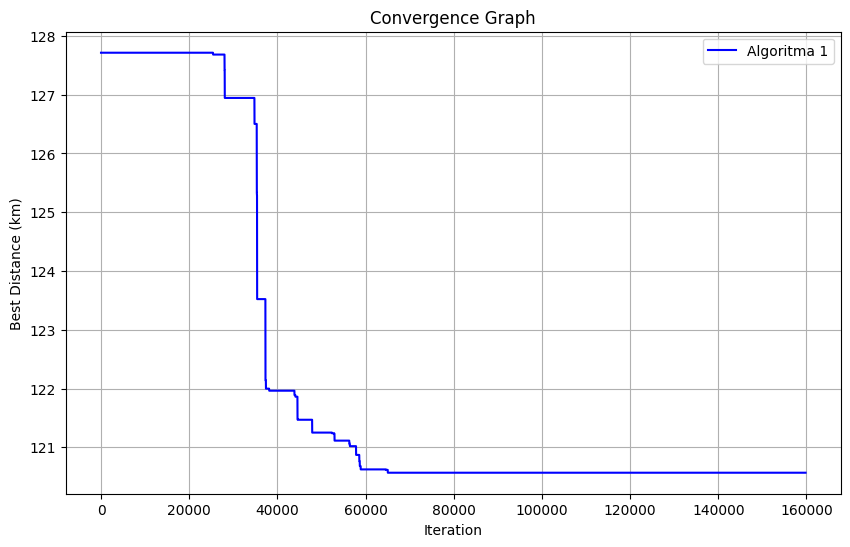

In [ ]:
# Cari index run dengan total distance terkecil
best_run_idx = np.argmin(distances)

# Ambil history convergence dari run tersebut
best_run_history = conv_hists[best_run_idx]

convergence_sa_2opt = best_run_history
plot_convergence( convergence_sa_2opt)


# Convergence graph 3 algorithm

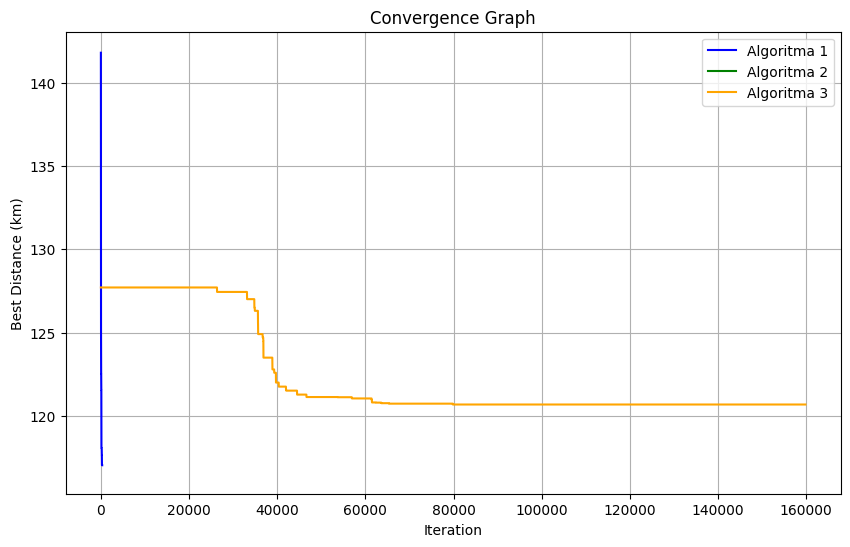

In [ ]:
plot_convergence(convergence_aco, convergence_pso_tabu, convergence_sa_2opt)


In [ ]:
plot_convergence(convergence_aco, convergence_pso_tabu, convergence_ga, labels=['ACO', 'PSO+Tabu', 'GA'])

NameError: name 'convergence_ga' is not defined